In [17]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as L
import torchmetrics
import optuna
from optuna.integration import PyTorchLightningPruningCallback
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from collections import Counter
import h5py
import gc

In [18]:
with h5py.File("train_data.h5", "r") as f:
    max_label = max(f["labels"])
    print(f"The maximum label index in your dataset is: {max_label}")

The maximum label index in your dataset is: 7


In [19]:
NUM_CLASSES = 8
N_TRIALS = 10
HYP_EPOCHS = 10
TRAIN_EPOCHS = 30
CURRENT_LABEL_MAP = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4, 'L': 5, 'C': 6, 'H': 7}
#CURRENT_LABEL_MAP = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4}
SET_INFO_MAP = {
    'S1': {'person': 0, 'env': 0},
    'S2': {'person': 0, 'env': 0},
    'S3': {'person': 1, 'env': 0},
    'S4': {'person': 0, 'env': 1},
    'S5': {'person': 1, 'env': 1},
    'S6': {'person': 0, 'env': 2},
    'S7': {'person': 2, 'env': 3},
}

In [20]:
class SHARPTrainDataset(Dataset):
    def __init__(self, h5_path="train_data.h5"):
        self.h5_path = h5_path
        print(f"Loading {h5_path} entirely into RAM for maximum speed...")
        
        with h5py.File(self.h5_path, 'r') as f:
            # The [:] reads the entire dataset from disk into a NumPy array in RAM
            self.features = f['features'][:]
            self.labels = f['labels'][:]
            
        self.length = len(self.labels)
        print(f"Loaded {self.length} train samples into memory.")

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        # Now fetches instantly from RAM, no disk I/O!
        window = self.features[idx]
        label = self.labels[idx]
        
        return torch.from_numpy(window).unsqueeze(0), torch.tensor(label, dtype=torch.long)

In [21]:
class SHARPTestDataset(Dataset):
    def __init__(self, h5_path="test_data.h5"):
        self.h5_path = h5_path
        print(f"Loading {h5_path} entirely into RAM for maximum speed...")
        
        with h5py.File(self.h5_path, 'r') as f:
            self.features = f['features'][:]
            self.labels = f['labels'][:]
            
        self.length = len(self.labels)
        print(f"Loaded {self.length} test samples into memory.")

    def __len__(self):
        return self.length
    
    def __getitem__(self, idx):
        streams = self.features[idx]
        label = self.labels[idx]
        
        return (
            torch.from_numpy(streams[0]).unsqueeze(0),
            torch.from_numpy(streams[1]).unsqueeze(0),
            torch.from_numpy(streams[2]).unsqueeze(0),
            torch.from_numpy(streams[3]).unsqueeze(0),
            torch.tensor(label, dtype=torch.long)
        )

In [22]:
class SHARP_Original_Architecture(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.2):
        super().__init__()
        
        # Keeps inputs stable without altering the architecture's capacity
        self.input_norm = nn.BatchNorm2d(1) 
        
        # Branch 1: Max Pooling
        self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Branch 2: 5 filters, 2x2 kernel, stride 2
        self.branch2 = nn.Sequential(
            nn.Conv2d(1, 5, kernel_size=2, stride=2), 
            nn.ReLU()
        )
        
        # Branch 3: Multi-scale extraction
        self.branch3 = nn.Sequential(
            nn.Conv2d(1, 3, kernel_size=1, stride=1), 
            nn.ReLU(),
            nn.ZeroPad2d((0, 1, 0, 1)), 
            nn.Conv2d(3, 6, kernel_size=2, stride=1), 
            nn.ReLU(),
            nn.Conv2d(6, 9, kernel_size=4, stride=2, padding=1), 
            nn.ReLU()
        )
        
        # Concat processing: Reduces the 15 stacked feature maps down to 3
        self.concat_conv = nn.Sequential(
            nn.Conv2d(15, 3, kernel_size=1, stride=1), 
            nn.ReLU()
        )
        
        self.flatten = nn.Flatten()
        
        # The paper explicitly states they use a 0.2 dropout rate before the final dense layer
        self.dropout = nn.Dropout(dropout)
        
        # Maps the 25,500 features directly to the output classes. No hidden layers!
        self.dense = nn.Linear(25500, num_classes)

    def forward(self, x):
        x = self.input_norm(x) 
        x = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
        x = self.concat_conv(x)
        x = self.flatten(x)
        x = self.dropout(x)
        x = self.dense(x)
        return x

In [23]:
# class SHARP_Original_Architecture(nn.Module):
#     def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
#         super().__init__()
        
#         # 1. Input Normalizer (CRITICAL for raw Wi-Fi data)
#         self.input_norm = nn.BatchNorm2d(1)
        
#         self.branch1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
#         # 2. Added BatchNorms to all Conv layers to stabilize gradients
#         self.branch2 = nn.Sequential(
#             nn.Conv2d(1, 5, 2, 2), 
#             nn.BatchNorm2d(5), 
#             nn.ReLU()
#         )
#         self.branch3 = nn.Sequential(
#             nn.Conv2d(1, 3, 1, 1), nn.BatchNorm2d(3), nn.ReLU(),
#             nn.ZeroPad2d((0, 1, 0, 1)), 
#             nn.Conv2d(3, 6, 2, 1), nn.BatchNorm2d(6), nn.ReLU(),
#             nn.Conv2d(6, 9, 4, 2, 1), nn.BatchNorm2d(9), nn.ReLU()
#         )
#         self.concat_conv = nn.Sequential(
#             nn.Conv2d(15, 3, 1, 1), 
#             nn.BatchNorm2d(3), 
#             nn.ReLU()
#         )
#         self.flatten = nn.Flatten()
        
#         # 3. UPGRADED CLASSIFIER: Gives the model the capacity to actually learn!
#         self.classifier = nn.Sequential(
#             nn.Dropout(dropout),
#             nn.Linear(25500, 256),      # Hidden layer to process the 25,500 features
#             nn.BatchNorm1d(256),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(256, num_classes) # Final output
#         )

#     def forward(self, x):
#         # UNCOMMENTED THIS! The network needs this to survive.
#         x = self.input_norm(x) 
        
#         x = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
#         x = self.concat_conv(x)
#         x = self.flatten(x)
#         x = self.classifier(x)
#         return x

In [24]:
def soft_decision_fusion(logits_list):
    """
    Applies Softmax to convert logits to probabilities, then averages them.
    This prevents one loud/wrong antenna from dominating the decision.
    """
    # 1. Convert all logits to probabilities
    probs_list =[torch.softmax(logits, dim=1) for logits in logits_list]
    
    # 2. Stack and average the probabilities:[4, batch_size, num_classes] -> [batch_size, num_classes]
    avg_probs = torch.mean(torch.stack(probs_list), dim=0)
    
    # 3. Final prediction is the class with the highest average probability
    return torch.argmax(avg_probs, dim=1)

In [ ]:
def sharp_decision_fusion(logits_list, Nant=4):
    """
    Implements the SHARP fusion logic: 
    If Nant-1 labels agree, use that. Otherwise, sum vectors.
    """
    # Get labels for each antenna
    labels = [torch.argmax(logits, dim=1) for logits in logits_list]
    batch_size = labels[0].shape[0]
    final_preds =[]

    for i in range(batch_size):
        votes = [l[i].item() for l in labels]
        counts = Counter(votes)
        
        # If at least Nant-1 (3 out of 4) agree
        if any(count >= (Nant - 1) for count in counts.values()):
            final_preds.append(counts.most_common(1)[0][0])
        else:
            # Fallback: Sum probability vectors
            probs =[torch.softmax(l[i], dim=0) for l in logits_list]
            avg_probs = torch.stack(probs).mean(dim=0)
            final_preds.append(torch.argmax(avg_probs).item())
            
    return torch.tensor(final_preds, device=logits_list[0].device)

In [25]:
class OPERAnetDataModule(L.LightningDataModule):
    # Notice we don't need root_dir anymore because we use the pre-built .h5 files
    def __init__(self, train_h5="train_data.h5", test_h5="test_data.h5", batch_size=64):
        super().__init__()
        self.train_h5 = train_h5
        self.test_h5 = test_h5
        self.batch_size = batch_size
        self.train_ds = None
        self.val_ds = None
        self.test_ds = None

    def setup(self, stage=None):
        # 1. Training/Validation Stage
        if stage == "fit" or stage is None:
            full_train_ds = SHARPTrainDataset(self.train_h5)
            train_size = int(0.75 * len(full_train_ds))
            val_size = len(full_train_ds) - train_size
            self.train_ds, self.val_ds = torch.utils.data.random_split(
                full_train_ds,[train_size, val_size]
            )
            print(f"Setup 'fit': {len(self.train_ds)} train, {len(self.val_ds)} val")
            
        # 2. Testing Stage
        if stage == "test" or stage is None:
            self.test_ds = SHARPTestDataset(self.test_h5)
            print(f"Setup 'test': {len(self.test_ds)} test samples (4-antenna fusion)")

    def train_dataloader(self):
        # Now you can safely increase num_workers=4 or 8 for extreme speed boosts!
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, pin_memory=True, num_workers=0)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, pin_memory=True, num_workers=0)

    def test_dataloader(self):
        if self.test_ds is None:
            self.setup(stage="test")
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, pin_memory=True, num_workers=0)

In [ ]:
class LitSHARP(L.LightningModule):
    def __init__(self, num_classes=NUM_CLASSES, lr=1e-4, dropout=0.2, weight_decay=1e-6):
        super().__init__()
        self.save_hyperparameters()
        self.model = SHARP_Original_Architecture(num_classes=num_classes, dropout=dropout)
        
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_preds = []
        self.test_labels =[]

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y, label_smoothing=0.05) 
        
        self.train_acc(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", self.train_acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        
        self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", self.val_acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x1, x2, x3, x4, y = batch
        logits =[self(x1), self(x2), self(x3), self(x4)]
        
        #preds = soft_decision_fusion(logits)
        preds = sharp_decision_fusion(logits, Nant=4)
        self.test_preds.extend(preds.cpu().numpy())
        self.test_labels.extend(y.cpu().numpy())

        acc = (preds == y).float().mean()
        self.log("test_fusion_acc", acc)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.hparams.lr, 
            weight_decay=self.hparams.weight_decay
        )
        
        #Removed 'verbose=True' to fix the TypeError in newer PyTorch versions
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='max', 
            factor=0.5, 
            patience=3 
        )
        
        return {
            "optimizer": optimizer, 
            "lr_scheduler": {
                "scheduler": scheduler, 
                "monitor": "val_acc", 
                "interval": "epoch"
            }
        }

In [27]:
def plot_confusion_matrix(true_labels, pred_labels):
    if len(true_labels) == 0: return
    
    # FIX 3: Update the names to match your new label_map
    activity_names = ['Empty', 'Walk', 'Run', 'Jump', 'Sit', 'Stand', 'Sit/Stand', 'Gym']
    #activity_names = ['Empty', 'Walk', 'Run', 'Jump', 'Sit']
    # Force a 5x5 matrix
    cm = confusion_matrix(true_labels, pred_labels, labels=range(NUM_CLASSES))
    cm_perc = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-8)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=activity_names, yticklabels=activity_names)
    plt.title('Normalized Confusion Matrix: Unseen Datasets (8-Class)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [28]:
from optuna.visualization import plot_optimization_history, plot_param_importances

def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True) # Increased L2 Regularization
    
    # Let Optuna find the perfect dropout rate to prevent overfitting
    #dropout = trial.suggest_float("dropout", 0.2, 0.7) 
    
    model = LitSHARP(lr=lr, dropout=0.2, weight_decay=weight_decay)
    datamodule = OPERAnetDataModule(batch_size=batch_size)

    trainer = L.Trainer(
        max_epochs=HYP_EPOCHS, 
        accelerator="auto",
        devices=1,
        logger=False, 
        enable_checkpointing=False,
        enable_progress_bar=True,
        callbacks=[PyTorchLightningPruningCallback(trial, monitor="val_acc")],
        enable_model_summary=False
    )

    trainer.fit(model, datamodule=datamodule)
    
    # Get the score before we delete the model
    val_acc = trainer.callback_metrics["val_acc"].item()
    
    # ==========================================
    # CRITICAL FIX: PREVENT WINDOWS RAM FREEZE
    # ==========================================
    del datamodule
    del model
    del trainer
    torch.cuda.empty_cache()
    gc.collect() # Forces Python to delete the 10GB dataset from RAM immediately
    
    return val_acc


if __name__ == "__main__":
    torch.set_float32_matmul_precision('high')
    
    print("\n--- OPTIMIZING HYPERPARAMETERS ---")
    study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5))
    study.optimize(objective, n_trials=N_TRIALS)
    # 1. Print a detailed text summary of the best trial
    print("\n--- OPTUNA STUDY RESULTS ---")
    best_trial = study.best_trial
    
    print(f"Best Validation Accuracy: {best_trial.value:.4f}")
    print("Best Parameters:")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")
    
    print("\n--- BEST PARAMS FOUND ---")
    print(study.best_params)
    
    # --- LOAD BEST HYPERPARAMETERS
    # Path to the hyperparameters of your best previous run
    # yaml_path = "logs/sharp_experiment/version_0/hparams.yaml" 
    # with open(yaml_path, "r") as f:
    #     config = yaml.safe_load(f)
    
    # # Note: CSVLogger might nest these under a 'hyperparameters' key
    # # or just list them directly depending on the version.
    # dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=config["batch_size"])
    # model = LitSHARP(
    #     lr=config["lr"], 
    #     weight_decay=config["weight_decay"], 
    #     dropout=config["dropout"]
    # )
    
    # --- DEFINE MANUAL PARAMS ---
    # manual_params = {
    #    "lr": 1e-3,
    #    "batch_size": 64,
    #    "weight_decay": 1e-4,
    #    "dropout": 0.3
    # }
    
    # --- USE MANUAL PARAMS ---
    # dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=manual_params["batch_size"])
    # model = LitSHARP(
    #    lr=manual_params["lr"], 
    #    weight_decay=manual_params["weight_decay"], 
    #   dropout=manual_params["dropout"]
    # )
    
    dm = OPERAnetDataModule(batch_size=study.best_params["batch_size"])
    model = LitSHARP(lr=study.best_params["lr"], weight_decay=study.best_params["weight_decay"], dropout=0.2)

    logger = CSVLogger("logs", name="sharp_experiment")
    checkpoint_callback = ModelCheckpoint(monitor="val_acc", dirpath="checkpoints", filename="best-sharp", mode="max")
    
    trainer = L.Trainer(
        max_epochs=TRAIN_EPOCHS,
        accelerator="auto",      
        devices=1,               
        callbacks=[checkpoint_callback],
        precision="16-mixed",     
        logger=logger
    )

    print("\n--- TRAINING FINAL MODEL ---")
    trainer.fit(model, datamodule=dm)

    print("\n--- TESTING ON S2-S7 COMBINED ---")
    trainer.test(model, datamodule=dm)

[I 2026-05-11 15:57:29,294] A new study created in memory with name: no-name-e3b526b9-0eff-48dd-ad0a-265fdb064913



--- OPTIMIZING HYPERPARAMETERS ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Loading train_data.h5 entirely into RAM for maximum speed...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Loaded 10436 train samples into memory.
Setup 'fit': 7827 train, 2609 val
Epoch 29: 100%|██████████| 245/245 [00:05<00:00, 47.13it/s, v_num=11, train_loss=1.020, train_acc=0.632, val_loss=1.320, val_acc=0.456]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 245/245 [00:05<00:00, 46.99it/s, v_num=11, train_loss=1.020, train_acc=0.632, val_loss=1.320, val_acc=0.456]

--- TESTING ON S2-S7 COMBINED ---
Loading test_data.h5 entirely into RAM for maximum speed...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\YeXiaoJun\anaconda3\envs\torch_env\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Loaded 6687 test samples into memory.
Setup 'test': 6687 test samples (4-antenna fusion)
Testing DataLoader 0: 100%|██████████| 209/209 [00:04<00:00, 44.53it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     test_fusion_acc        0.5130850672721863
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Plotting metrics from: logs/sharp_experiment\version_11


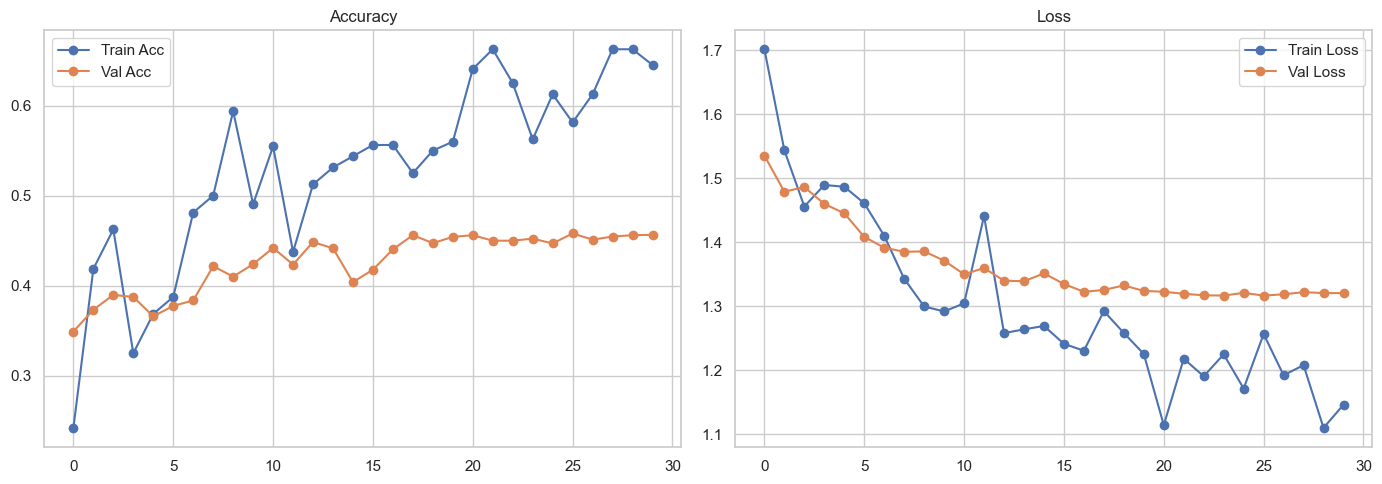

In [29]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_latest_learning_curves(base_log_dir):
    # 1. Automatically find the folder with the highest version number
    version_folders = glob.glob(os.path.join(base_log_dir, "version_*"))
    if not version_folders:
        print(f"No version folders found in {base_log_dir}")
        return
        
    latest_version = max(version_folders, key=lambda x: int(x.split('_')[-1]))
    metrics_path = os.path.join(latest_version, "metrics.csv")
    
    print(f"Plotting metrics from: {latest_version}")
    
    if not os.path.exists(metrics_path):
        print("metrics.csv not found yet. Has the model started training?")
        return
        
    df = pd.read_csv(metrics_path)
    
    # 2. Fix potential NaN issues in the epoch column
    # Lightning logs can have NaNs in the epoch column for step-level training metrics.
    # We backfill so training steps are associated with the correct epoch.
    df['epoch'] = df['epoch'].bfill()
    df_epoch = df.groupby('epoch').mean().reset_index()
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Accuracy ---
    if 'train_acc' in df_epoch.columns:
        axes[0].plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Acc', marker='o')
    if 'val_acc' in df_epoch.columns:
        axes[0].plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Acc', marker='o')
    axes[0].set_title('Accuracy')
    axes[0].legend()
    
    # --- Loss ---
    if 'train_loss' in df_epoch.columns:
        axes[1].plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss', marker='o')
    if 'val_loss' in df_epoch.columns:
        axes[1].plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss', marker='o')
    axes[1].set_title('Loss')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# Run this after training is finished
plot_latest_learning_curves("logs/sharp_experiment")

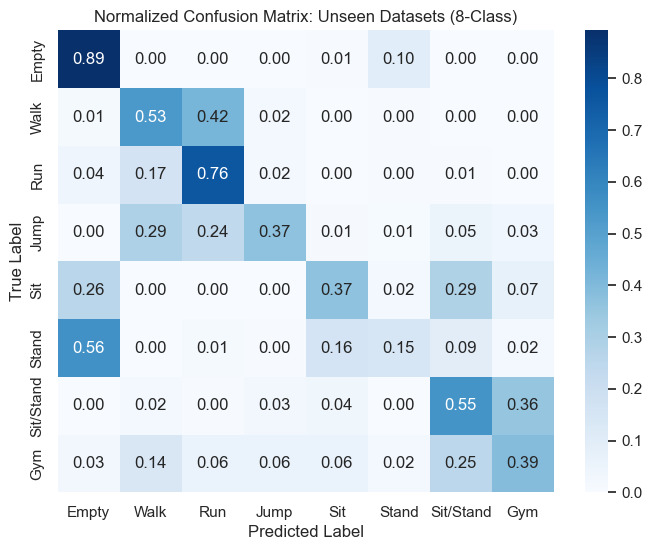

In [30]:
# Plot final results
plot_confusion_matrix(model.test_labels, model.test_preds)

In [31]:
# import pytorch_lightning as L

# # 1. Provide the exact path to your saved .ckpt file
# # (Check your directory structure to confirm the exact name and path)
# CHECKPOINT_PATH = "checkpoints/best-sharp-v7.ckpt" 

# # 2. Load the model directly from the weights file
# # Lightning automatically restores the architecture and the exact hyperparameters (lr, dropout, etc.)
# print(f"Loading weights from {CHECKPOINT_PATH}...")
# model = LitSHARP.load_from_checkpoint(CHECKPOINT_PATH)

# # Put the model into evaluation mode (disables dropout, freezes batch norm)
# model.eval() 

# # 3. Initialize your DataModule for testing
# # (You don't need to specify learning rates or train sets here, just the batch size for testing)
# dm = OPERAnetDataModule(root_dir="doppler_traces", batch_size=64)

# # Force the DataModule to run its setup for the "test" stage
# # This loads S2-S7 (or whatever you set in your DataModule's test_ds)
# dm.setup(stage="test") 

# # 4. Create a lightweight Trainer strictly for testing
# tester = L.Trainer(
#     accelerator="auto", 
#     devices=1, 
#     logger=False,                 # No need to log to CSV just for a quick test
#     enable_model_summary=False    # Keeps console output clean
# )

# # 5. Run the test!
# print("\n--- RUNNING QUICK TEST ---")
# tester.test(model, datamodule=dm)

# # 6. (Optional) Plot the confusion matrix again
# plot_confusion_matrix(model.test_labels, model.test_preds)

Loading train_data.h5 entirely into RAM for maximum speed...
Loaded 10436 train samples into memory.
Setup 'fit': 7827 train, 2609 val
Loading test_data.h5 entirely into RAM for maximum speed...
Loaded 6687 test samples into memory.
Setup 'test': 6687 test samples (4-antenna fusion)


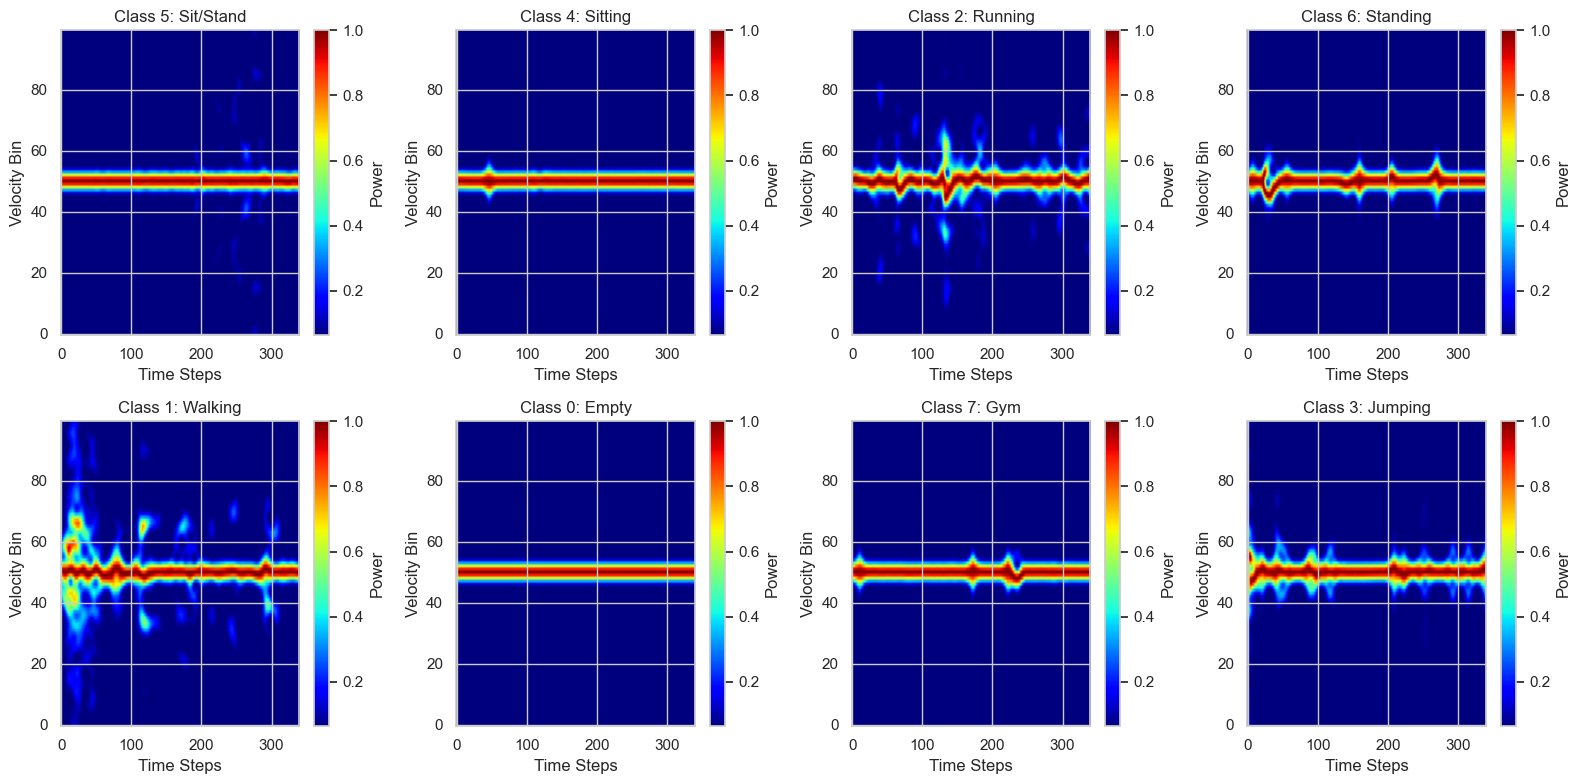

In [32]:
def plot_sample_activities(dataset, label_map):
    # Dynamically find the number of target classes
    num_classes = len(label_map)
    # Map the letters directly to their full names dynamically
    letter_to_name = {
        'E': 'Empty', 'W': 'Walking', 'R': 'Running', 'J': 'Jumping',
        'S': 'Sitting', 'C': 'Standing', 'L': 'Sit/Stand', 'H': 'Gym'
    }
    
    # Create {ID: Name} mapping using your actual label_map
    id_to_name = {v: letter_to_name[k] for k, v in label_map.items()}
    
    found_classes = set()
    
    # Adjust figure size based on how many classes we have
    cols = 4 if num_classes > 5 else 5
    rows = (num_classes + cols - 1) // cols
    plt.figure(figsize=(4 * cols, 4 * rows))
    
    count = 0
    # Search for one example of each class
    for i in range(len(dataset)):
        x, y = dataset[i]
        label = y.item()
        
        if label not in found_classes:
            found_classes.add(label)
            count += 1
            
            plt.subplot(rows, cols, count)
            # Remove channel dim and transpose so Time is X and Velocity is Y
            plt.imshow(x.squeeze().numpy().T, aspect='auto', origin='lower', cmap='jet')
            
            plt.title(f"Class {label}: {id_to_name[label]}")
            plt.xlabel("Time Steps")
            plt.ylabel("Velocity Bin")
            plt.colorbar(label="Power") # Added a colorbar to see the threshold!
            
            # Dynamically break when we find exactly the number of classes in the map
            if len(found_classes) == num_classes: 
                break
            
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN IT ---
# Make sure to pass your current 5-class dictionary!
#CURRENT_LABEL_MAP = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4}
dm = OPERAnetDataModule()
dm.setup()
CURRENT_LABEL_MAP = {'E': 0, 'W': 1, 'R': 2, 'J': 3, 'S': 4, 'L': 5, 'C': 6, 'H': 7}
plot_sample_activities(dm.train_ds, CURRENT_LABEL_MAP)